# Olist E-Commerce Analytics: Category-Specific Cancellation & Operational Attribution
*Project Scope: Phase 2 - Micro-Level Deep Dive (2017 - 2018)*

## Continuity from Phase 1
In the previous analysis, **[01_platform_order_trends_and_cancellation_baseline.ipynb](./01_platform_order_trends_and_cancellation_baseline.ipynb)**, I visualized platform-wide fulfillment trends and established that the overall cancellation rate remained remarkably stable—consistently below 2% from May 2017 onward. Even during the November Black Friday sales peak, the cancellation rate did not rise. This effectively ruled out systemic IT failures or traffic overload, prompting this secondary investigation into category-specific operational drivers.

### Filtering Outliers & Noise
In this phase, I shifted focus to product categories but intentionally ignored those with low order volumes. When a category only has a few orders, a single cancellation can easily distort the percentage—making it look like a huge problem when it is just a random event.

### Isolating Three Strategic Targets
To focus strictly on real operational issues rather than random noise, I cross-analyzed categories with monthly trends using a heatmap. This successfully isolated three specific targets where order volumes are substantial enough to warrant a root-cause investigation:
* **April 2018:** A sharp increase in cancellations for **Construction Tools & Garden**.
* **July 2018:** A noticeable spike in **Telephony** cancellations.
* **August 2017:** A high cancellation rate in **Fashion & Male Clothing** despite consistent sales volume.


## 1. Data Ingestion & Initial Inspection
I load the four raw datasets from Olist and take an initial glance at their structures, shapes, and column data types to understand the baseline schema before processing.

In [ ]:
# connect to kaggel
import os
import zipfile
import pandas as pd

os.environ['KAGGLE_USERNAME'] = "changyingkang"
os.environ['KAGGLE_KEY'] = "KGAT_46d5f875a7ae806b7a866f2ea340ab33"
!kaggle datasets download -d olistbr/brazilian-ecommerce

with zipfile.ZipFile("brazilian-ecommerce.zip", "r") as zip_ref:
    zip_ref.extractall("olist_data")

print(os.listdir("olist_data"))

# getting csv
df_products = pd.read_csv('olist_data/olist_products_dataset.csv')
df_items = pd.read_csv('olist_data/olist_order_items_dataset.csv')
df_translation = pd.read_csv('olist_data/product_category_name_translation.csv')



Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
['olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'product_category_name_translation.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_customers_dataset.csv', 'olist_products_dataset.csv']


In [ ]:
# glance at data

folder_path = 'olist_data'

for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        temp_df = pd.read_csv(file_path)

        print("="*50)
        print(f"file name: {file_name}")
        print(f"columns and rows: {temp_df.shape}")
        print("-"*50)
        print("dtype and lists:")
        print(temp_df.dtypes)
        print("-"*30)
        print("head2:")
        display(temp_df.head(2))
        print("\n")

file name: olist_order_items_dataset.csv
columns and rows: (112650, 7)
--------------------------------------------------
dtype and lists:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object
------------------------------
head2:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93




file name: olist_order_payments_dataset.csv
columns and rows: (103886, 5)
--------------------------------------------------
dtype and lists:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
------------------------------
head2:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39




file name: product_category_name_translation.csv
columns and rows: (71, 2)
--------------------------------------------------
dtype and lists:
product_category_name            object
product_category_name_english    object
dtype: object
------------------------------
head2:


...

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP




file name: olist_customers_dataset.csv
columns and rows: (99441, 5)
--------------------------------------------------
dtype and lists:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
------------------------------
head2:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP




file name: olist_products_dataset.csv
columns and rows: (32951, 9)
--------------------------------------------------
dtype and lists:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object
------------------------------
head2:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


## 2. Preliminary Category Merging & Evaluation
I consolidate the datasets and calculate the baseline cancellation rates for each product category based on the entire raw dataset. This ranking helps identify immediate statistical noise caused by low-volume product lines before applying any timeline filters.

In [ ]:
# 1. Load Olist datasets
orders = pd.read_csv('olist_data/olist_orders_dataset.csv')
items = pd.read_csv('olist_data/olist_order_items_dataset.csv')
products = pd.read_csv('olist_data/olist_products_dataset.csv')
translation = pd.read_csv('olist_data/product_category_name_translation.csv')

# 2. Trim whitespace from joining keys to ensure accurate mapping
products['product_category_name'] = products['product_category_name'].astype(str).str.strip()
translation['product_category_name'] = translation['product_category_name'].astype(str).str.strip()

# 3. Map Portuguese category names to English translations
products_translated = pd.merge(products, translation, on='product_category_name', how='left')
products_translated['product_category_name_english'] = products_translated['product_category_name_english'].fillna(products_translated['product_category_name'])

# 4. Merge order items with the translated product categories
order_items_with_category = pd.merge(items, products_translated[['product_id', 'product_category_name_english']], on='product_id', how='left')

# 5. Combine order status with product metadata for comprehensive analysis
full_order_data = pd.merge(orders, order_items_with_category, on='order_id', how='left')

# 6. Group by category to calculate total orders and canceled/unavailable volume
category_analysis = full_order_data.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    canceled_orders=('order_status', lambda x: x.isin(['canceled', 'unavailable']).sum())
).reset_index()

# 7. Calculate the cancellation + unavailability rate
category_analysis['cancellation_rate_%'] = ((category_analysis['canceled_orders'] / category_analysis['total_orders']) * 100).round(2)

# 8. Filter and sort the top 10 categories with the highest cancellation rates
top_10_canceled_categories = category_analysis.sort_values(by='cancellation_rate_%', ascending=False).head(10)

print("Top 10 Cancelled Product Categories")
display(top_10_canceled_categories)

Top 10 Cancelled Product Categories


,product_category_name_english,total_orders,canceled_orders,cancellation_rate_%
60,pc_gamer,8,1,12.50
63,portateis_cozinha_e_preparadores_de_alimentos,14,1,7.14
23,diapers_and_hygiene,27,1,3.70
25,dvds_blu_ray,59,2,3.39
19,construction_tools_safety,167,5,2.99
21,costruction_tools_garden,194,4,2.06
56,musical_instruments,628,11,1.75
34,fixed_telephony,217,3,1.38
8,books_general_interest,512,7,1.37
45,home_appliances_2,234,3,1.28


## 3. High-Volume Category Screening & Time-Series Aggregation
To eliminate the small-sample bias shown in the unconstrained ranking above, I apply a strict volume threshold filter (`total_orders > 100`) to isolate the top 10 categories with the most significant long-term business impact. This step successfully filters out the noise and allows representative categories with genuine operational issues—such as *Fashion & Male Clothing*—to surface in our final pool.

Within this same cell, I break the data down into monthly and yearly cohorts, incorporating an anti-noise baseline control (`total_qty < 5`) to prevent temporary low-volume periods from distorting the tracking matrix displayed below.

In [ ]:
import numpy as np
import pandas as pd

# 1. Load raw dataset
orders = pd.read_csv('olist_data/olist_orders_dataset.csv')
items = pd.read_csv('olist_data/olist_order_items_dataset.csv')
products = pd.read_csv('olist_data/olist_products_dataset.csv')
translation = pd.read_csv('olist_data/product_category_name_translation.csv')

# 2. Data cleaning and text trimming
products = products.dropna(subset=['product_category_name'])
products['product_category_name'] = products['product_category_name'].astype(str).str.strip()
translation['product_category_name'] = translation['product_category_name'].astype(str).str.strip()

# 3. Join tables
products_translated = pd.merge(products, translation, on='product_category_name', how='inner')
order_items_with_category = pd.merge(items, products_translated[['product_id', 'product_category_name_english']], on='product_id', how='inner')
full_order_data = pd.merge(orders, order_items_with_category, on='order_id', how='inner')

# 4. Clean datetime and exclude 2016 data
full_order_data['order_purchase_timestamp'] = pd.to_datetime(full_order_data['order_purchase_timestamp'])
full_order_data['order_month'] = full_order_data['order_purchase_timestamp'].dt.to_period('M').astype(str)
full_order_data['order_year'] = full_order_data['order_purchase_timestamp'].dt.year.astype(str)
full_order_data = full_order_data[full_order_data['order_year'] != '2016']

# 5. Find top 10 product category with highest cancellation rate (orders>100)
overall_category = full_order_data.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    canceled_orders=('order_status', lambda x: x.isin(['canceled', 'unavailable']).sum())
).reset_index()
overall_category['overall_rate_%'] = (overall_category['canceled_orders'] / overall_category['total_orders']) * 100
top_10_names = overall_category[overall_category['total_orders'] > 100].sort_values(by='overall_rate_%', ascending=False).head(10)['product_category_name_english'].tolist()

# 6. Column label setting
def wrap_text(text):
    text = text.replace('_', ' ')
    if len(text) > 15:
        words = text.split(' ')
        if len(words) <= 1:
            mid = len(text) // 2
            return text[:mid] + '\n' + text[mid:]
        mid_word_idx = len(words) // 2
        return '\n'.join([' '.join(words[:mid_word_idx]), ' '.join(words[mid_word_idx:])])
    return text

wrapped_top_10_names = [wrap_text(name) for name in top_10_names]

# 7. Year/month average data calculation
monthly_data = full_order_data.groupby(['order_month', 'product_category_name_english']).agg(
    total_qty=('order_id', 'nunique'),
    canceled_qty=('order_status', lambda x: x.isin(['canceled', 'unavailable']).sum())
).reset_index().rename(columns={'order_month': 'time_period'})

# 8. Exclude product ordered < 5
monthly_data.loc[monthly_data['total_qty'] < 5, 'canceled_qty'] = 0
monthly_data.loc[monthly_data['total_qty'] < 5, 'total_qty'] = 0

yearly_data = full_order_data.groupby(['order_year', 'product_category_name_english']).agg(
    total_qty=('order_id', 'nunique'),
    canceled_qty=('order_status', lambda x: x.isin(['canceled', 'unavailable']).sum())
).reset_index()
yearly_data['time_period'] = yearly_data['order_year'] + '-Avg'
yearly_data = yearly_data.drop(columns=['order_year'])

# 9. Concat data and monthly+yearly average table
combined_data = pd.concat([yearly_data, monthly_data], ignore_index=True)
combined_data['rate_%'] = np.where(combined_data['total_qty'] > 0, ((combined_data['canceled_qty'] / combined_data['total_qty']) * 100).round(2), 0.0)

# 10. Setting cell appearance to cancellation rate %,(cancelled order counts/all order counts)
def make_display_format(row):
    return f"{row['rate_%']}% ({row['canceled_qty']}/{row['total_qty']})"

combined_data['cell_display'] = combined_data.apply(make_display_format, axis=1)

# pivot setting
pivot_numeric = combined_data[combined_data['product_category_name_english'].isin(top_10_names)].pivot(
    index='time_period', columns='product_category_name_english', values='rate_%'
).fillna(0)

pivot_labels = combined_data[combined_data['product_category_name_english'].isin(top_10_names)].pivot(
    index='time_period', columns='product_category_name_english', values='cell_display'
).fillna("0.0% (0/0)")

months_list = sorted([p for p in pivot_numeric.index if not p.endswith('-Avg')])
custom_order = []
for i, m in enumerate(months_list):
    custom_order.append(m)
    current_year = m.split('-')[0]
    if i == len(months_list) - 1 or months_list[i+1].split('-')[0] != current_year:
        avg_row_name = f"{current_year}-Avg"
        if avg_row_name in pivot_numeric.index:
            custom_order.append(avg_row_name)

pivot_numeric = pivot_numeric.reindex(custom_order)
pivot_labels = pivot_labels.reindex(custom_order)


print("2017-2018 Cancellation rate summary")
styled_pivot = pivot_labels.style.set_properties(**{
    'width': '200px',
    'max-width': '200px',
    'text-align': 'center',
    'vertical-align': 'middle',
    'white-space': 'normal',
    'line-height': '1.4'
}).set_table_styles([{
    'selector': 'th',
    'props': [
        ('width', '200px'), ('max-width', '200px'),
        ('text-align', 'center'), ('white-space', 'normal'),
        ('line-height', '1.4'), ('padding', '10px 5px')
    ]
}])

styled_pivot.columns = wrapped_top_10_names
display(styled_pivot)

2017-2018 Cancellation rate summary


product_category_name_english,books_general_interest,consoles_games,construction_tools_safety,costruction_tools_garden,fashion_male_clothing,fixed_telephony,food_drink,home_appliances_2,musical_instruments,small_appliances
time_period,,,,,,,,,,
2017-01,0.0% (0/0),0.0% (0/21),0.0% (0/0),0.0% (0/0),0.0% (0/0),0.0% (0/19),0.0% (0/0),0.0% (0/7),0.0% (0/0),0.0% (0/6)
2017-02,0.0% (0/8),0.0% (0/18),0.0% (0/0),0.0% (0/0),0.0% (0/7),0.0% (0/18),0.0% (0/0),0.0% (0/0),0.0% (0/8),0.0% (0/25)
2017-03,5.0% (1/20),2.08% (1/48),0.0% (0/0),0.0% (0/0),0.0% (0/7),6.67% (1/15),20.0% (1/5),0.0% (0/0),0.0% (0/9),0.0% (0/31)
2017-04,0.0% (0/12),0.0% (0/15),0.0% (0/0),0.0% (0/7),0.0% (0/6),0.0% (0/7),0.0% (0/0),0.0% (0/0),0.0% (0/16),0.0% (0/21)
2017-05,0.0% (0/19),0.0% (0/26),0.0% (0/0),16.67% (1/6),0.0% (0/0),0.0% (0/10),0.0% (0/12),0.0% (0/9),0.0% (0/19),0.0% (0/16)
2017-06,0.0% (0/20),0.0% (0/27),0.0% (0/0),0.0% (0/0),0.0% (0/8),0.0% (0/12),0.0% (0/0),0.0% (0/6),0.0% (0/17),0.0% (0/23)
2017-07,0.0% (0/12),0.0% (0/46),0.0% (0/0),0.0% (0/7),0.0% (0/8),0.0% (0/8),0.0% (0/7),0.0% (0/7),7.14% (2/28),3.03% (1/33)
2017-08,3.45% (1/29),0.0% (0/85),0.0% (0/0),0.0% (0/7),0.0% (0/13),0.0% (0/14),0.0% (0/12),11.76% (2/17),16.67% (4/24),0.0% (0/32)
2017-09,0.0% (0/15),1.64% (1/61),0.0% (0/0),0.0% (0/5),0.0% (0/10),0.0% (0/6),0.0% (0/6),0.0% (0/6),0.0% (0/24),6.25% (2/32)


## 4. Dual-Color Heatmap Visualization
I generate the final customized heatmap matrix to visualize the operational trends. The visualization applies a red color gradient (`Reds`) for monthly data cohorts, while explicitly overriding the yearly average (`-Avg`) rows with a blue color gradient (`Blues`) to establish a clear visual hierarchy.

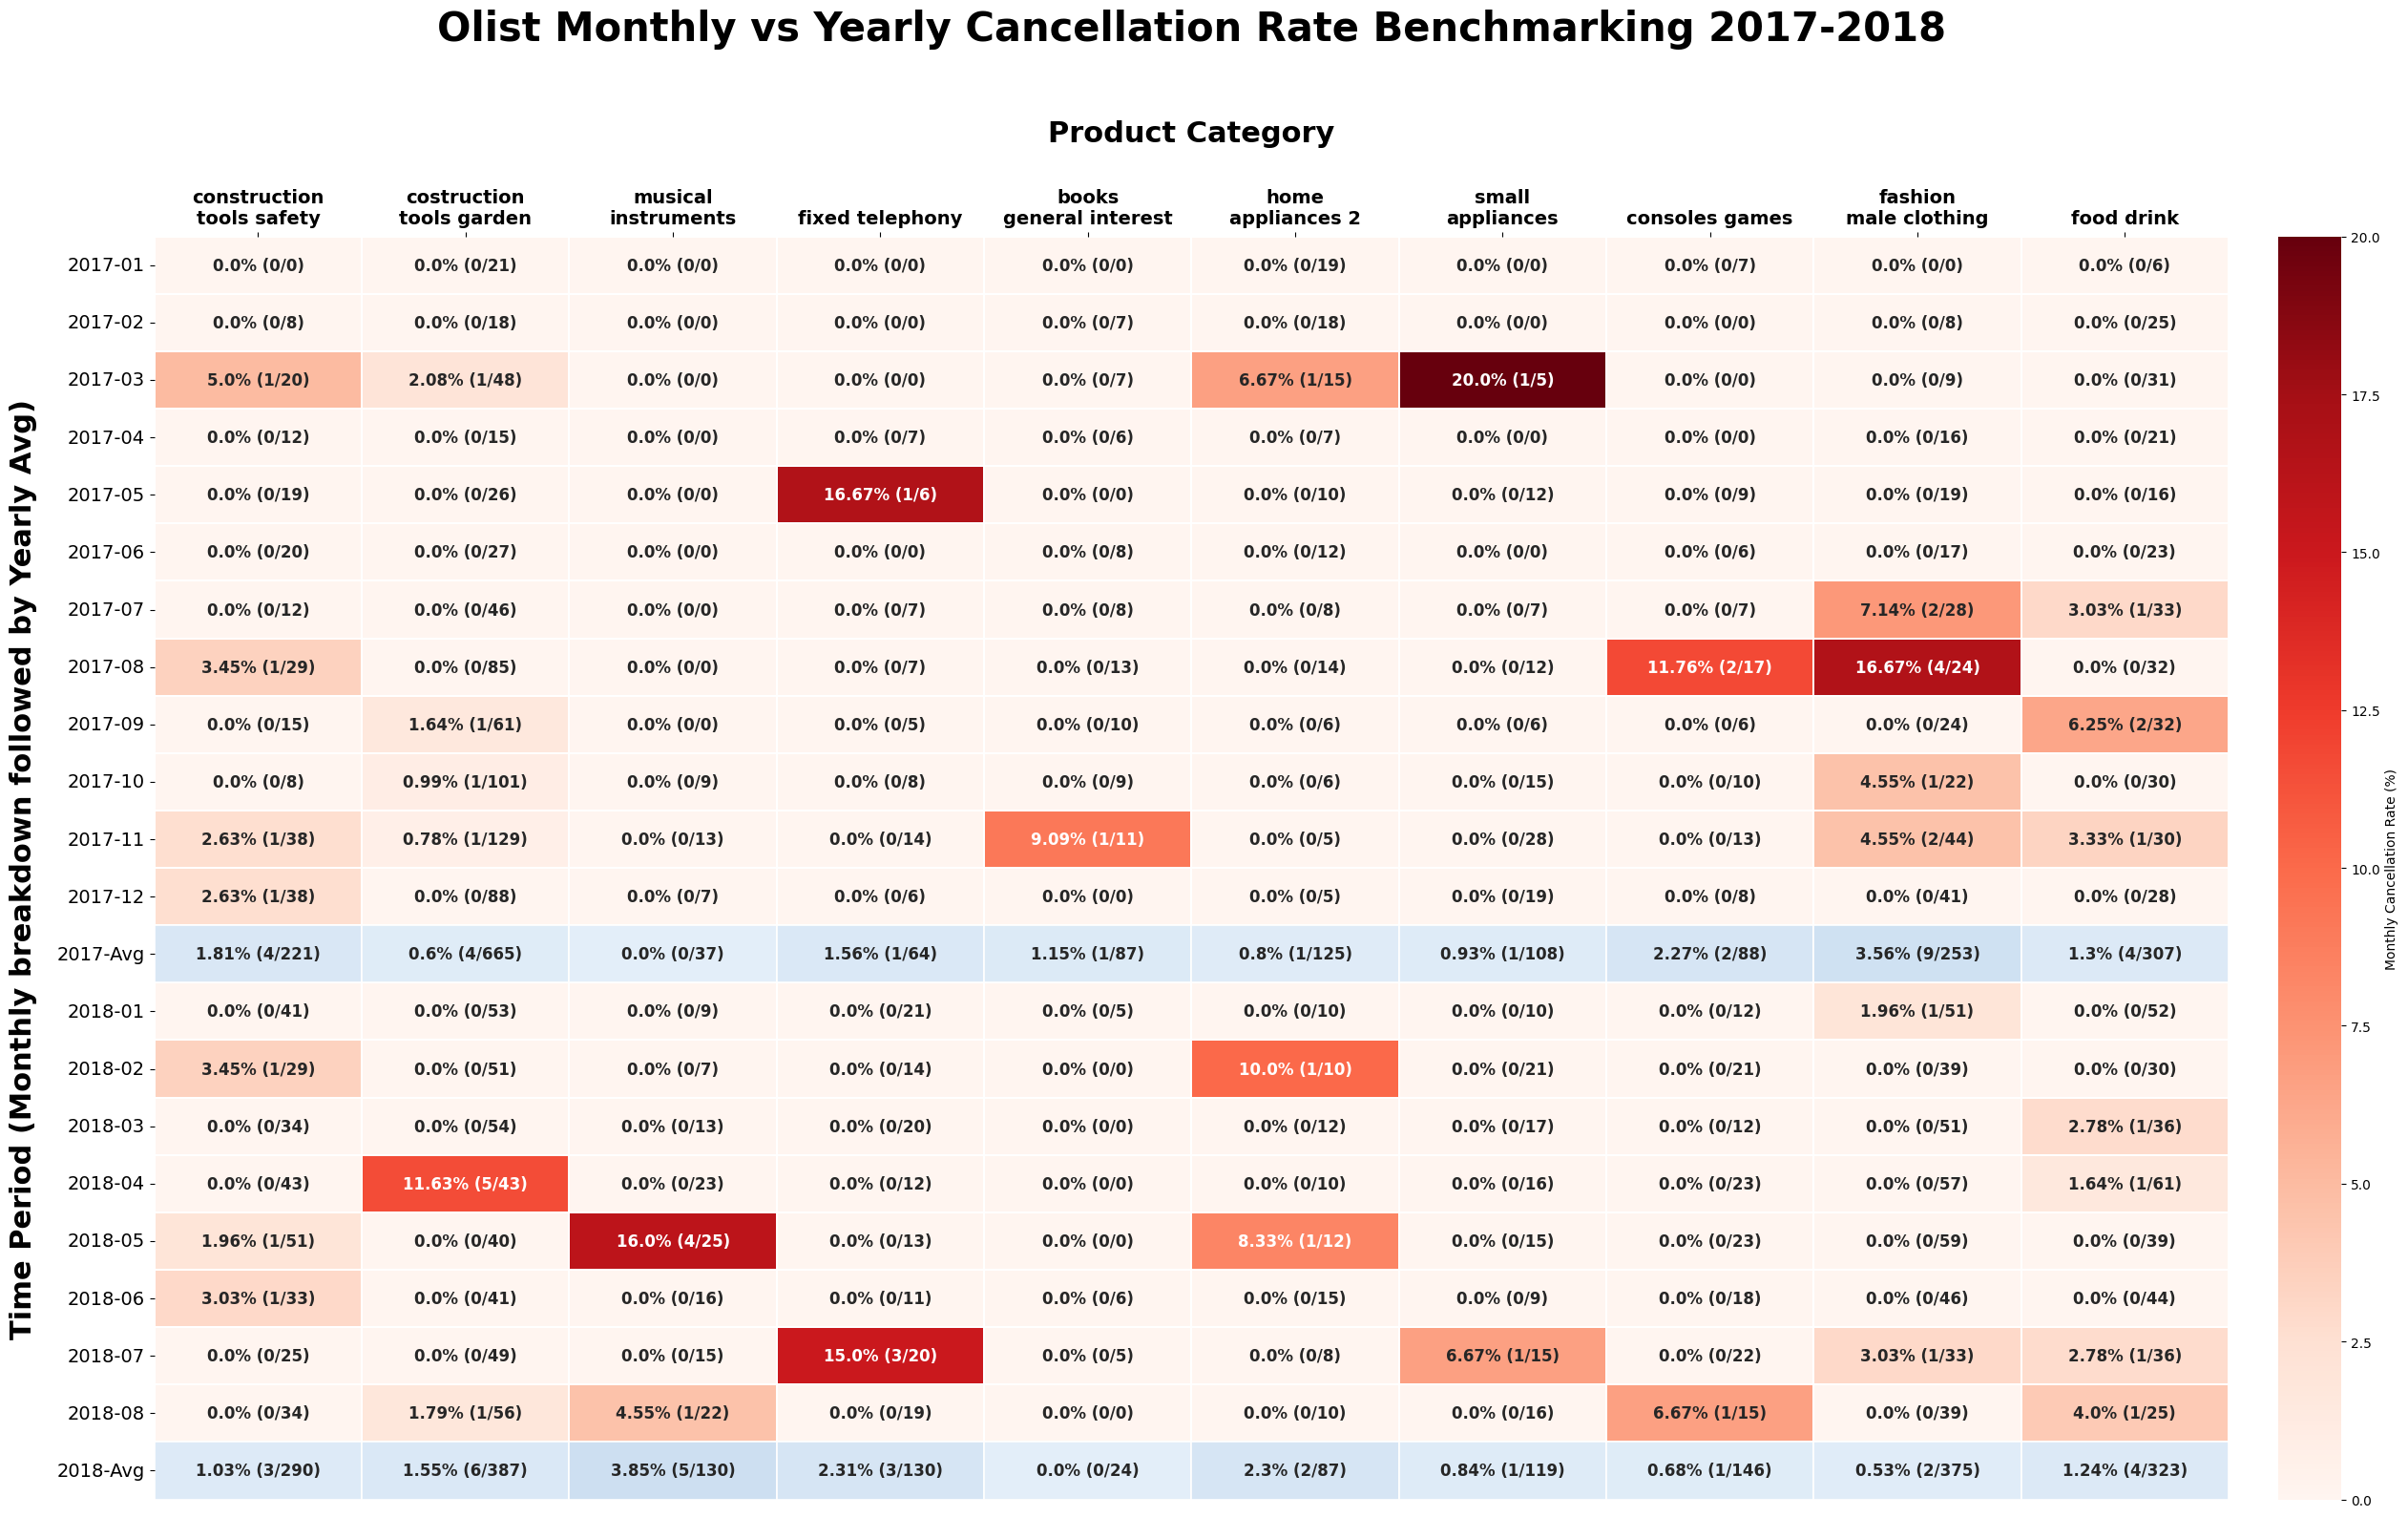

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

# 1. Heatmap setting
fig, ax = plt.subplots(figsize=(28, 16))
sns.heatmap(
    pivot_numeric,
    annot=pivot_labels.values,
    fmt="",
    cmap='Reds',
    linewidths=1.2,
    cbar_kws={'label': 'Monthly Cancellation Rate (%)', 'pad': 0.02},
    annot_kws={"size": 12, "weight": "bold"},
    ax=ax
)

# 2. Yearly average row setting
blue_cmap = plt.cm.Blues

for row_idx, time_idx in enumerate(pivot_numeric.index):
    if time_idx.endswith('-Avg'):
        for col_idx in range(pivot_numeric.shape[1]):
            val = pivot_numeric.iloc[row_idx, col_idx]
            max_val = pivot_numeric.max().max() if pivot_numeric.max().max() > 0 else 100
            norm_val = val / max_val
            color_rgb = blue_cmap(0.1 + 0.6 * norm_val)
            rect = ax.collections[0].get_paths()[row_idx * pivot_numeric.shape[1] + col_idx]
            ax.add_patch(plt.Polygon(rect.vertices, facecolor=color_rgb, edgecolor='#ffffff', linewidth=1.2))

# 3. Xlabel setting
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xticklabels(wrapped_top_10_names, rotation=0, fontsize=14, ha='center', fontweight='bold')
plt.yticks(fontsize=14)

# 4. Title and labels setting
ax.set_title('Olist Monthly vs Yearly Cancellation Rate Benchmarking 2017-2018', fontsize=30, pad=60, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=22, labelpad=35,fontweight='bold')
ax.set_ylabel('Time Period (Monthly breakdown followed by Yearly Avg)', fontsize=22, labelpad=15,fontweight='bold')

plt.tight_layout()

plt.savefig('top_10_cancellation_perfect_mixed.png', dpi=300, bbox_inches='tight')
### 📊 Heatmap Matrix Interpretation & Key Takeaways
Each cell in this matrix displays the monthly cancellation rate for the respective category, calculated as the count of canceled and unavailable orders over total order volume.

The dual-color encoding allows an analyst to instantly spot high-percentage anomalies via color density, while the overlaid volume metrics provide immediate context to determine if a spike is statistically significant or driven by low-volume noise. Through this cross-examination, I isolated the three primary targets introduced at the beginning of this report:
* **Construction Tools & Garden** (April 2018)
* **Telephony** (July 2018)
* **Fashion & Male Clothing** (August 2017)plt.show()

###  Heatmap Matrix Interpretation & Key Takeaways
Each cell in this matrix displays the monthly cancellation rate for the respective category, calculated as the count of canceled and unavailable orders over total order volume.

The dual-color encoding allows an analyst to instantly spot high-percentage anomalies via color density, while the overlaid volume metrics provide immediate context to determine if a spike is statistically significant or driven by low-volume noise. Through this cross-examination, I isolated the three primary targets introduced at the beginning of this report:
* **Construction Tools & Garden** (April 2018)
* **Telephony** (July 2018)
* **Fashion & Male Clothing** (August 2017)



### Next Steps
To uncover the precise root causes behind the three localized anomalies identified, the next phase of this project will focus on:
* **User Behavioral Analysis:** Profile buyer segments to detect potential cluster cancellations or customer friction during those specific months.
* **Review Sentiment Mining:** Extract and analyze customer feedback within `review_comment_message` for high-frequency complaints regarding stockouts or delivery delays.